In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
df = pd.read_csv("credit_card_fraud_2026.csv")

In [ ]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["merchant_category"] = le.fit_transform(df["merchant_category"])
df["card_type"] = le.fit_transform(df["card_type"])
df["auth_method"] = le.fit_transform(df["auth_method"])
df["channel"] = le.fit_transform(df["channel"])
df["device_type"] = le.fit_transform(df["device_type"])

In [ ]:
df.isnull().sum()

,0
transaction_id,0
amount_usd,0
merchant_category,0
card_type,0
auth_method,0
channel,0
device_type,0
is_foreign_transaction,0
hours_since_last_txn,0
txn_count_last_24h,0


In [ ]:
for col in df.select_dtypes(include = "object").columns:
  le = labelEncoder()
  df[col] = le.fit_transfrom(df[col])

In [ ]:
df.select_dtypes(include = "object").columns

Index([], dtype='object')

In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 16000
Testing : 4000


In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
prediction = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)
print("Accuracy Percentage :", accuracy * 100)

Accuracy : 0.96775
Accuracy Percentage : 96.775


In [ ]:
cm = confusion_matrix(y_test, prediction)

print(cm)

[[3862   72]
 [  57    9]]


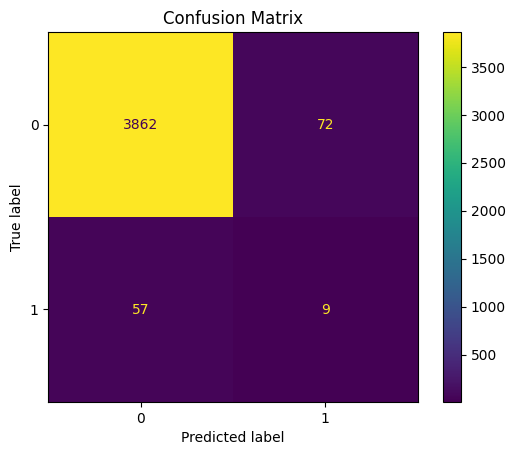

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, prediction)

plt.title("Confusion Matrix")
plt.show()

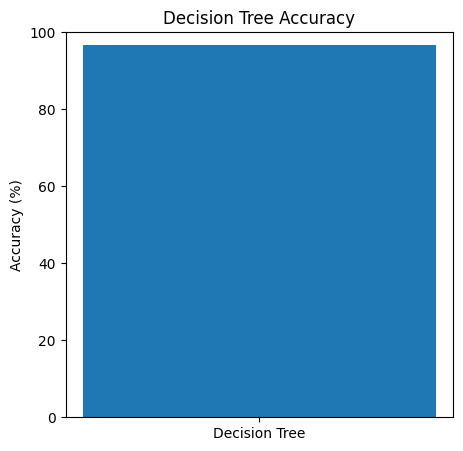

In [ ]:
plt.figure(figsize=(5,5))

plt.bar(["Decision Tree"], [accuracy * 100])

plt.title("Decision Tree Accuracy")
plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

plt.show()

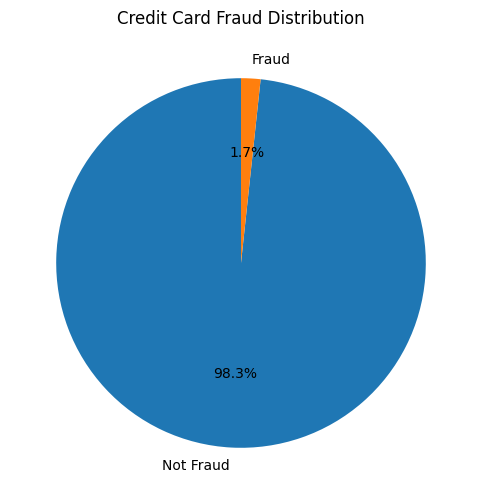

In [ ]:
fraud = df["is_fraud"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(fraud,
        labels=["Not Fraud","Fraud"],
        autopct = "%1.1f%%",
        startangle = 90)

plt.title("Credit Card Fraud Distribution")
plt.show()

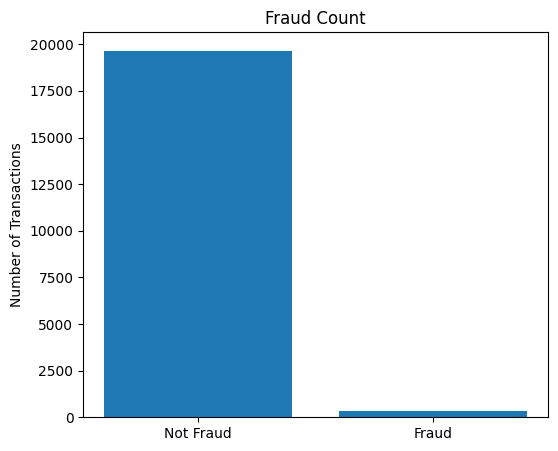

In [ ]:
fraud = df["is_fraud"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(["Not Fraud","Fraud"], fraud)

plt.title("Fraud Count")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
print(X.columns)

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes'],
      dtype='object')


In [ ]:
X.columns.tolist()

['transaction_id',
 'amount_usd',
 'merchant_category',
 'card_type',
 'auth_method',
 'channel',
 'device_type',
 'is_foreign_transaction',
 'hours_since_last_txn',
 'txn_count_last_24h',
 'distance_from_home_km',
 'card_age_months',
 'customer_age',
 'account_balance_usd',
 'is_new_merchant',
 'used_vpn',
 'ip_country_mismatch',
 'billing_shipping_mismatch',
 'cvv_retry_count',
 'velocity_score',
 'time_of_day_hour',
 'day_of_week',
 'is_ai_generated_scam_attempt',
 'merchant_risk_score',
 'prior_disputes']

In [ ]:
new_transaction = [[
10001,     # transaction_id
250.75,    # amount_usd
2,         # merchant_category (encoded value)
1,         # card_type
0,         # auth_method
1,         # channel
2,         # device_type
0,         # is_foreign_transaction
5,         # hours_since_last_txn
3,         # txn_count_last_24h
10.5,      # distance_from_home_km
24,        # card_age_months
30,        # customer_age
5000,      # account_balance_usd
0,         # is_new_merchant
0,         # used_vpn
0,         # ip_country_mismatch
0,         # billing_shipping_mismatch
1,         # cvv_retry_count
20,        # velocity_score
14,        # time_of_day_hour
3,         # day_of_week
0,         # is_ai_generated_scam_attempt
15,        # merchant_risk_score
0          # prior_disputes
]]

In [ ]:
prediction = model.predict(new_transaction)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
prediction = model.predict(new_transaction)

if prediction[0] == 0:
    print("Transaction is NOT Fraud")
else:
    print("Transaction is FRAUD")

Transaction is NOT Fraud


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
df[df["merchant_category"] == "Shopping"]

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud


In [ ]:
df["merchant_category"].value_counts()

,count
merchant_category,
7,3416
5,3242
8,2534
1,2032
2,1565
10,1420
11,1330
6,1237
3,1036


In [ ]:
df["merchant_category"].head()

,merchant_category
0,8
1,7
2,5
3,9
4,10


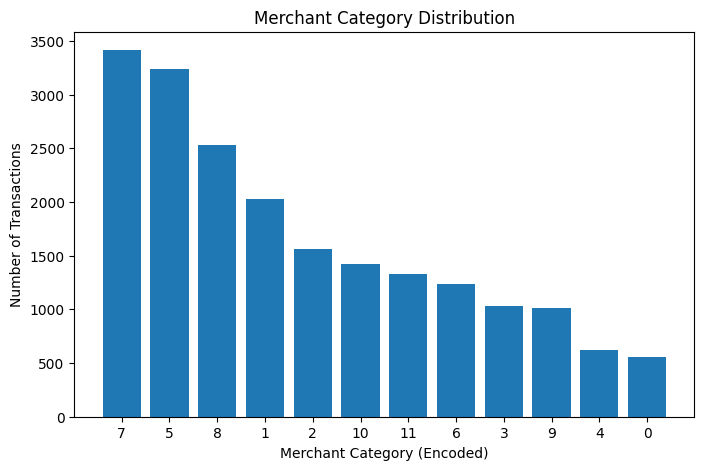

In [ ]:
merchant = df["merchant_category"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(merchant.index.astype(str), merchant.values)

plt.title("Merchant Category Distribution")
plt.xlabel("Merchant Category (Encoded)")
plt.ylabel("Number of Transactions")

plt.show()

In [ ]:
df = pd.read_csv("credit_card_fraud_2026.csv")

df_original = df.copy()    # Save original dataset

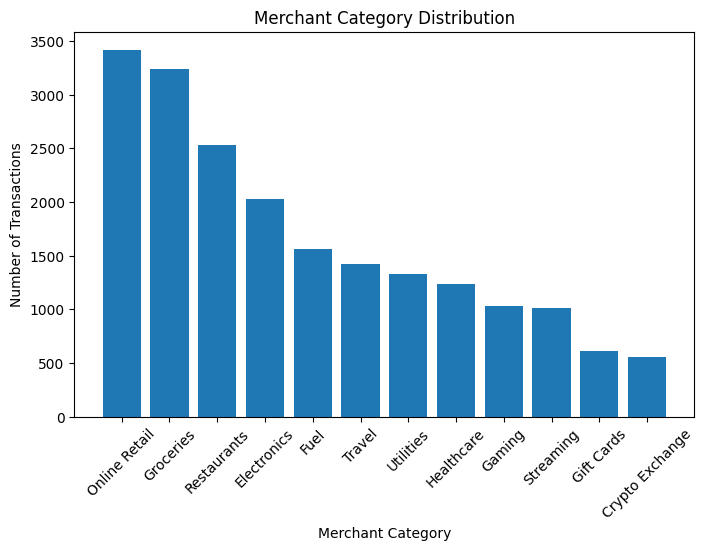

In [ ]:
merchant = df_original["merchant_category"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(merchant.index, merchant.values)

plt.title("Merchant Category Distribution")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()


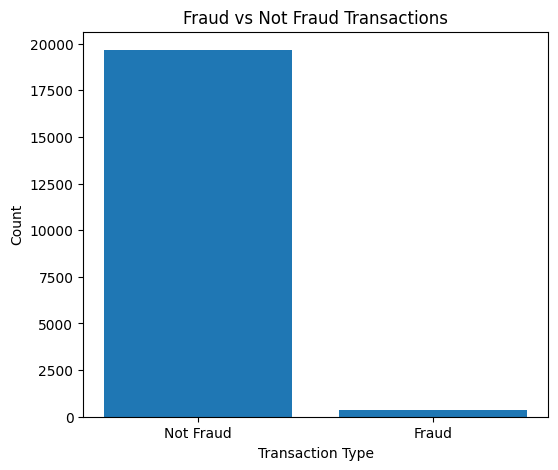

In [ ]:
fraud = df["is_fraud"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(["Not Fraud","Fraud"], fraud.values)

plt.title("Fraud vs Not Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()


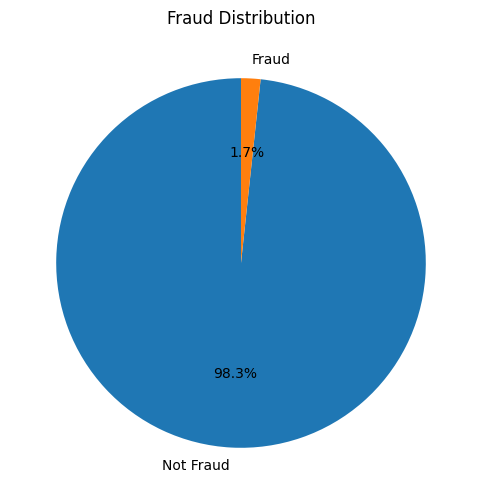

In [ ]:
fraud = df["is_fraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(fraud.values,
        labels=["Not Fraud","Fraud"],
        autopct="%1.1f%%",
        startangle=90)

plt.title("Fraud Distribution")

plt.show()

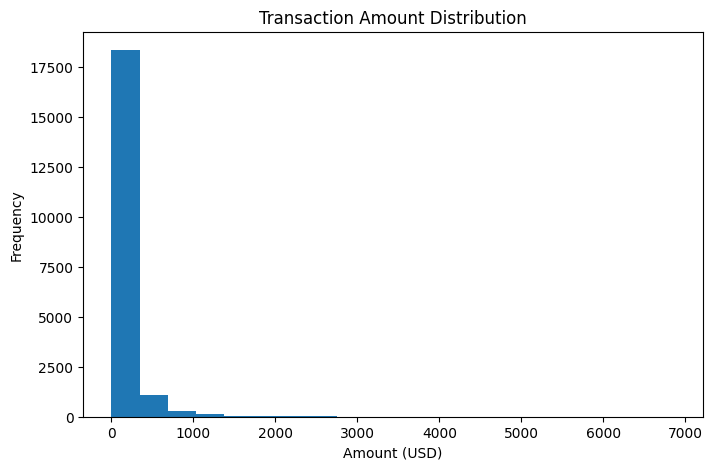

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["amount_usd"], bins=20)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount (USD)")
plt.ylabel("Frequency")

plt.show()

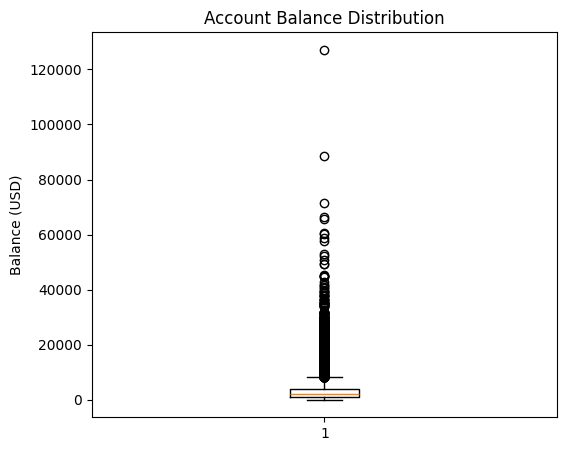

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(df["account_balance_usd"])

plt.title("Account Balance Distribution")
plt.ylabel("Balance (USD)")

plt.show()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
print(len(y_test))
print(len(prediction))

4000
4000


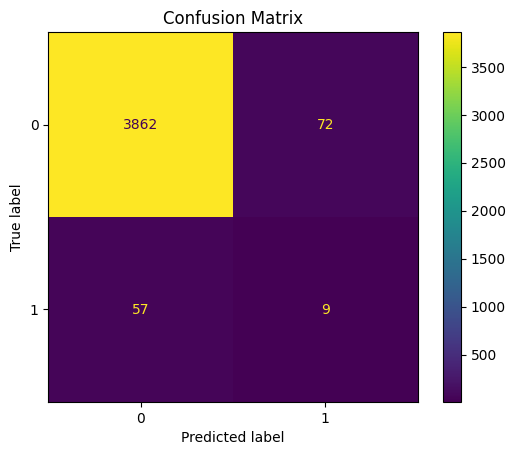

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, prediction)

plt.title("Confusion Matrix")
plt.show()

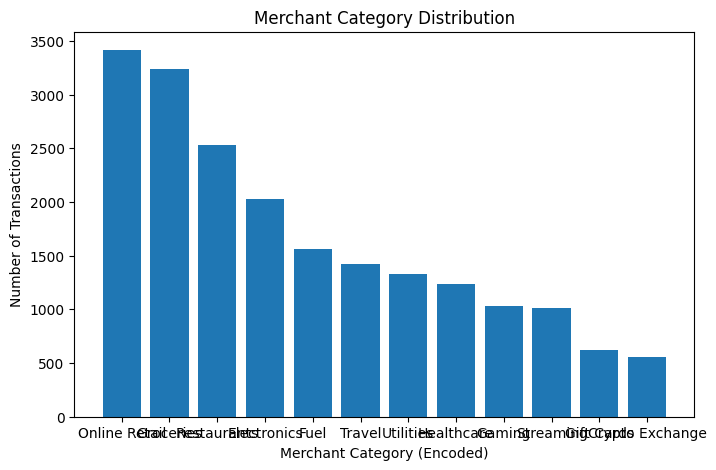

In [ ]:
merchant = df["merchant_category"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(merchant.index.astype(str), merchant.values)

plt.title("Merchant Category Distribution")
plt.xlabel("Merchant Category (Encoded)")
plt.ylabel("Number of Transactions")

plt.show()

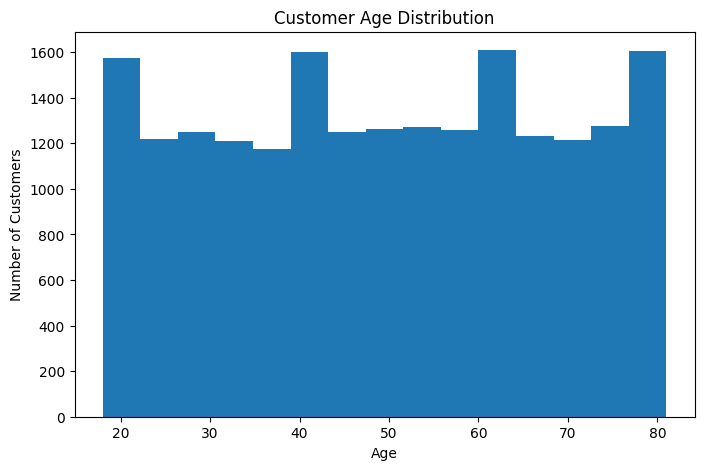

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["customer_age"], bins=15)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

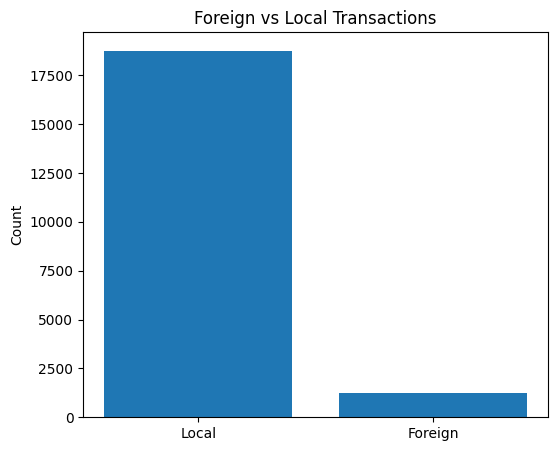

In [ ]:
foreign = df["is_foreign_transaction"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(["Local","Foreign"], foreign.values)

plt.title("Foreign vs Local Transactions")
plt.ylabel("Count")

plt.show()

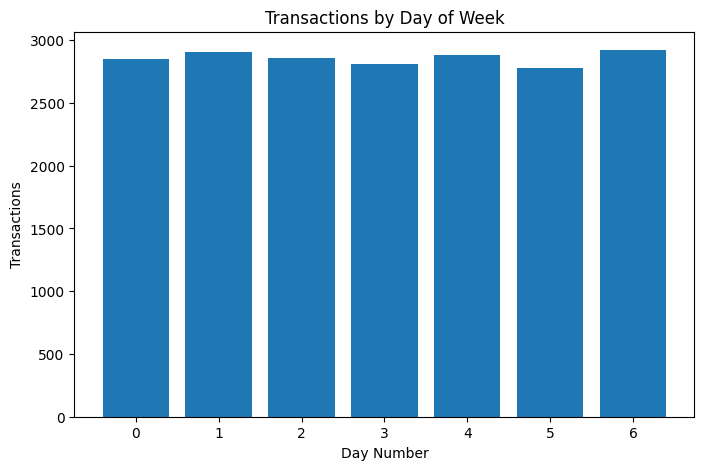

In [ ]:
days = df["day_of_week"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(days.index.astype(str), days.values)

plt.title("Transactions by Day of Week")
plt.xlabel("Day Number")
plt.ylabel("Transactions")

plt.show()

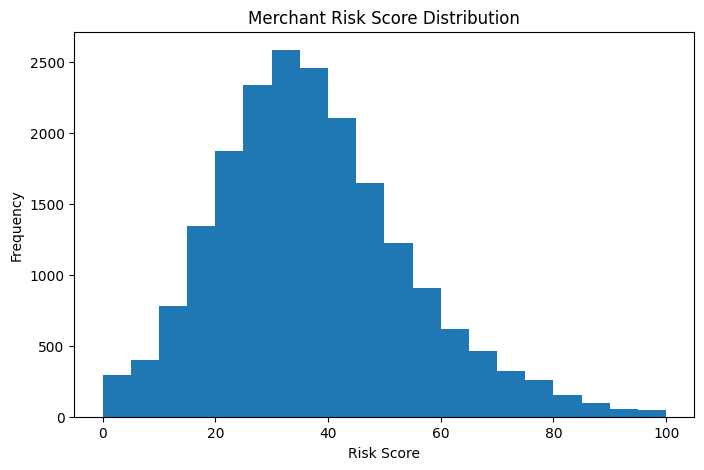

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["merchant_risk_score"], bins=20)

plt.title("Merchant Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

In [158]:
import joblib
from sklearn.preprocessing import LabelEncoder

encoders = {}

le1 = LabelEncoder()
df_original["merchant_category"] = df_original["merchant_category"].astype(str)
le1.fit(df_original["merchant_category"])
encoders["merchant_category"] = le1

le2 = LabelEncoder()
df_original["card_type"] = df_original["card_type"].astype(str)
le2.fit(df_original["card_type"])
encoders["card_type"] = le2

le3 = LabelEncoder()
df_original["auth_method"] = df_original["auth_method"].astype(str)
le3.fit(df_original["auth_method"])
encoders["auth_method"] = le3

le4 = LabelEncoder()
df_original["channel"] = df_original["channel"].astype(str)
le4.fit(df_original["channel"])
encoders["channel"] = le4

le5 = LabelEncoder()
df_original["device_type"] = df_original["device_type"].astype(str)
le5.fit(df_original["device_type"])
encoders["device_type"] = le5

joblib.dump(model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

from google.colab import files
files.download("model.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>